Let us simulate how different policy could impact the 

In [1]:
#!pip install prophet

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from prophet import Prophet


In [3]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## Introduction

The goal of this notebook is to predict juenile crime using a subset of historical data. 

What will the impact be over the next 5 years, if there was a policy that reduced the use of firearms by 20%.

In [4]:
# load data set
raw_data = pd.read_csv('dataset_1980_2020.csv')
raw_data.rename(columns={"Count": "Year"}, inplace=True)


weapon_columns = ["Firearm", "Knife", "Blunt object", "Personal", "Other/unknown Weapon"]
raw_data['Weapon_Total'] = raw_data[weapon_columns].sum(axis=1)


In [5]:
# Group by Year (national total)
national_data = raw_data.groupby("Year")[["Firearm", "Knife", "Blunt object", "Personal", "Other/unknown Weapon", "Weapon_Total"]].sum().reset_index()

print(national_data.head())
print(national_data.shape)


   Year  Firearm  Knife  Blunt object  Personal  Other/unknown Weapon  \
0  1980      816    355            97        86                    77   
1  1981      824    311           102        94                    62   
2  1982      641    292            89       114                    71   
3  1983      565    286            80        88                    71   
4  1984      504    209            63        69                    52   

   Weapon_Total  
0          1431  
1          1393  
2          1207  
3          1090  
4           897  
(41, 7)


Now using Prophet to forecast next 5 years (2021-2025)

In [6]:
df = national_data[["Year", "Firearm"]].rename(columns={"Year": "ds", "Firearm": "y"})
df["ds"] = pd.to_datetime(df["ds"], format="%Y")  # Convert to datetime

# Fit Prophet model
model = Prophet(yearly_seasonality=False, daily_seasonality=False, weekly_seasonality=False)
model.fit(df)

# Create a future dataframe for 2021-2025
future = model.make_future_dataframe(periods=6, freq='Y')

# Make predictions
forecast = model.predict(future)

# Extract 2021-2025 predictions
forecast_future = forecast[forecast["ds"].dt.year > df["ds"].dt.year.max()][["ds", "yhat"]]
forecast_future["Year"] = forecast_future["ds"].dt.year.astype(int)
forecast_future = forecast_future[["Year", "yhat"]].rename(columns={"yhat": "Firearm"})

print(forecast_future)

23:20:44 - cmdstanpy - INFO - Chain [1] start processing
23:20:44 - cmdstanpy - INFO - Chain [1] done processing


    Year     Firearm
42  2021  628.239721
43  2022  615.926843
44  2023  603.613966
45  2024  591.267354
46  2025  578.954477


The models that we will use to simulate the policy reduction include: linear regression, decision tree, random forest, and gradient boosting

In [7]:
X = national_data[["Year", "Firearm"]]  # Features: Year and Firearm incidents
y = national_data["Weapon_Total"]  # Target: Total weapon-related incidents

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Dictionary to store trained models
model_results = {}

# Train each model and store results
for model_name, model in models.items():
    model.fit(X, y)
    model_results[model_name] = model

Predictions shows overall decrease with implemntation of policy.

In [8]:
# Baseline scenario: Using forecasted Firearm values from Prophet
X_future_baseline = forecast_future.copy()

# Policy scenario: Reducing firearm incidents by 20%
X_future_policy = X_future_baseline.copy()
X_future_policy["Firearm"] *= 0.8  # Apply a 20% reduction to firearm incidents

# Dictionary to store simulation results for each model
simulation_results = {}

# Predict outcomes for both baseline and policy scenarios using all models
for model_name, model in model_results.items():
    # Predict for the baseline and policy scenarios
    y_pred_baseline = model.predict(X_future_baseline)
    y_pred_policy = model.predict(X_future_policy)
    
    # Calculate average outcomes for both scenarios
    avg_baseline = np.mean(y_pred_baseline)
    avg_policy = np.mean(y_pred_policy)
    change = avg_policy - avg_baseline
    
    # Store results for each model
    simulation_results[model_name] = {
        "baseline": y_pred_baseline,
        "policy": y_pred_policy,
        "avg_baseline": avg_baseline,
        "avg_policy": avg_policy,
        "change": change
    }
    
    # Print individual model results
    print(f"Model: {model_name}")
    print(f"Avg Predicted Outcome (Baseline): {avg_baseline:.2f}")
    print(f"Avg Predicted Outcome (Policy): {avg_policy:.2f}")
    print(f"Change (Policy - Baseline): {change:.2f}")

Model: Linear Regression
Avg Predicted Outcome (Baseline): 705.99
Avg Predicted Outcome (Policy): 573.25
Change (Policy - Baseline): -132.74
Model: Decision Tree
Avg Predicted Outcome (Baseline): 795.00
Avg Predicted Outcome (Policy): 680.60
Change (Policy - Baseline): -114.40
Model: Random Forest
Avg Predicted Outcome (Baseline): 831.67
Avg Predicted Outcome (Policy): 699.38
Change (Policy - Baseline): -132.29
Model: Gradient Boosting
Avg Predicted Outcome (Baseline): 776.17
Avg Predicted Outcome (Policy): 680.41
Change (Policy - Baseline): -95.76


Visualize

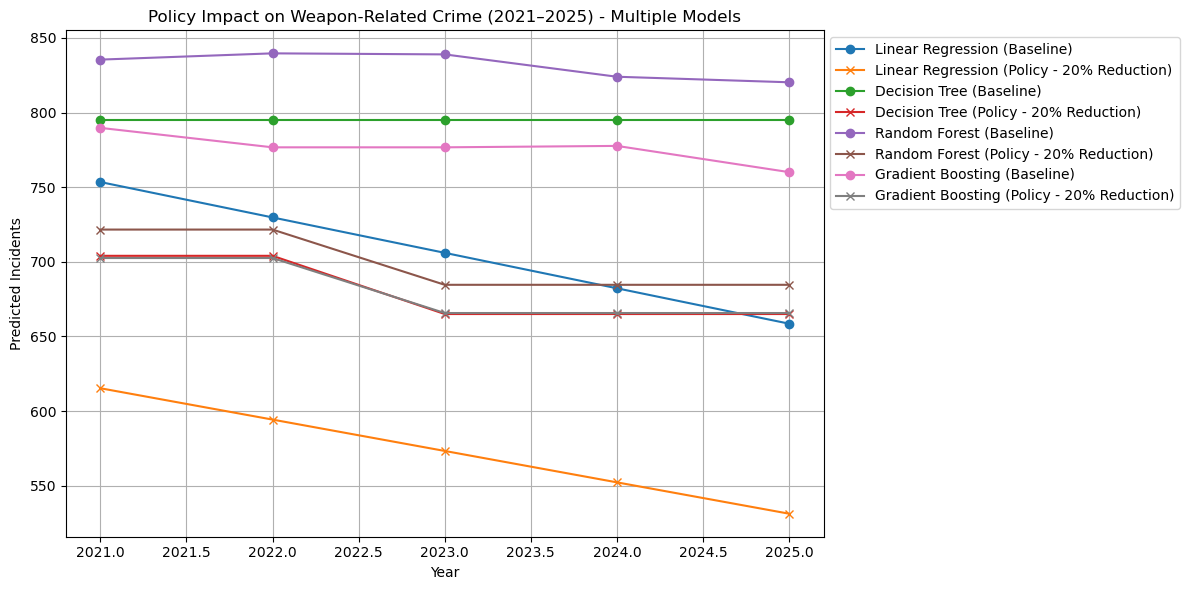

In [9]:
plt.figure(figsize=(12, 6))

for model_name, result in simulation_results.items():
    plt.plot(X_future_baseline["Year"], result["baseline"], label=f"{model_name} (Baseline)", marker='o')
    plt.plot(X_future_policy["Year"], result["policy"], label=f"{model_name} (Policy - 20% Reduction)", marker='x')

plt.title("Policy Impact on Weapon-Related Crime (2021–2025) - Multiple Models")
plt.xlabel("Year")
plt.ylabel("Predicted Incidents")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)
plt.tight_layout()
plt.show()